# Strawberry Counting: From Baseline to Fine-Tuned YOLO

This notebook demonstrates a complete workflow for building an object counter, starting from a simple baseline model and progressing to a fine-tuned YOLOv11 model.

We will cover:
1.  **Baseline Model**: Using OpenCV Template Matching for a quick and simple count.
2.  **Pre-trained YOLO**: Testing a generic, off-the-shelf YOLO model.
3.  **Fine-Tuning YOLO**: Training the YOLO model on our specific strawberry data.
4.  **Evaluation**: Comparing the results from the fine-tuned model.

In [1]:
import os
import sys
import cv2
import matplotlib.pyplot as plt

# Add src directory to path to import our custom modules
sys.path.append(os.path.abspath('src'))

# --- Configuration ---
# Define all the paths we will need
CWD = os.getcwd()
XML_PATH = os.path.join(CWD, 'dataset', 'annotations.xml')
IMAGES_DIR = os.path.join(CWD, 'dataset', 'images')
YOLO_DATASET_DIR = os.path.join(CWD, 'strawberry_dataset')
TEMPLATE_PATH = os.path.join(CWD, 'template', 'template.png')
BASELINE_OUT = os.path.join(CWD, 'output', 'baseline_result.png')
PRETRAINED_MODEL = 'yolo11s.pt'
FINETUNED_OUT_DIR = os.path.join(CWD, 'output', 'finetuned_preds')
PRETRAINED_OUT_DIR = os.path.join(CWD, 'output', 'pretrained_preds')

# Ensure output directories exist
os.makedirs('output', exist_ok=True)
os.makedirs('template', exist_ok=True)

In [2]:
from yolo_utils import split_and_prepare
if not os.path.exists(os.path.join(YOLO_DATASET_DIR, 'data.yaml')):
    split_and_prepare(XML_PATH, IMAGES_DIR, YOLO_DATASET_DIR)


## 1. Baseline Model: OpenCV Template Matching

Before diving into deep learning, we'll establish a baseline using a simple computer vision technique: template matching. This method works by sliding a "template" image (a small, cropped-out image of a strawberry) across a larger image to find matches.

It's fast but often struggles with variations in scale, rotation, and lighting.

2025-08-24 20:50:24,251 - INFO - Template saved to c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\template\template.png


Creating template from image 0...


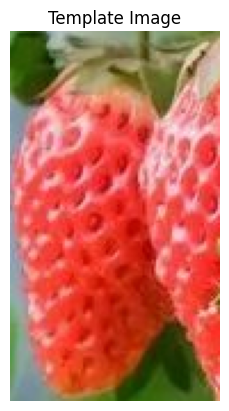

In [3]:
from baseline import create_template, run_baseline

# First, create a template from our dataset
print("Creating template from image 0...")
create_template(XML_PATH, IMAGES_DIR, TEMPLATE_PATH)

# Display the template
template_img = cv2.imread(TEMPLATE_PATH)
plt.imshow(cv2.cvtColor(template_img, cv2.COLOR_BGR2RGB))
plt.title("Template Image")
plt.axis('off')
plt.show()

2025-08-24 20:50:24,490 - INFO - Baseline detection complete - 1 items found.


Running baseline detection on c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\dataset\images\0.png...
Baseline detected 1 strawberries.


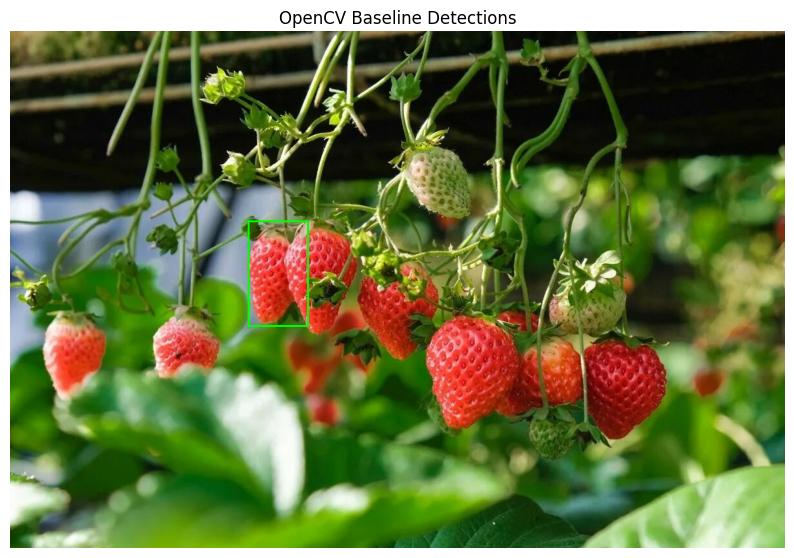

In [4]:
from yolo_utils import parse_annotations
data = parse_annotations(XML_PATH)
sample_image_path = os.path.join(IMAGES_DIR, data[0][0])
print(f"Running baseline detection on {sample_image_path}...")
baseline_count = run_baseline(sample_image_path, TEMPLATE_PATH, BASELINE_OUT)
print(f"Baseline detected {baseline_count} strawberries.")
baseline_result = cv2.imread(BASELINE_OUT)
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(baseline_result, cv2.COLOR_BGR2RGB))
plt.title("OpenCV Baseline Detections")
plt.axis('off')
plt.show()


## 2. Pre-trained YOLOv11 Inference

Now, let's see how a powerful, pre-trained YOLOv11 model performs without any specific training on our strawberries. This model has been trained on the large COCO dataset and can recognize 80 common object classes, but "strawberry" is not one of them. We are testing its ability to generalize.

Running pre-trained YOLOv11 inference on sample image c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\images\val\1.png...

image 1/1 c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\images\val\1.png: 384x640 8 apples, 3 potted plants, 108.0ms
Speed: 2.7ms preprocess, 108.0ms inference, 196.1ms postprocess per image at shape (1, 3, 384, 640)
Results saved to c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\output\pretrained_preds\predictions


2025-08-24 20:50:37,379 - INFO - Inference complete. Found 0 strawberry detections.


Pre-trained model detected 0 strawberries in the sample image.


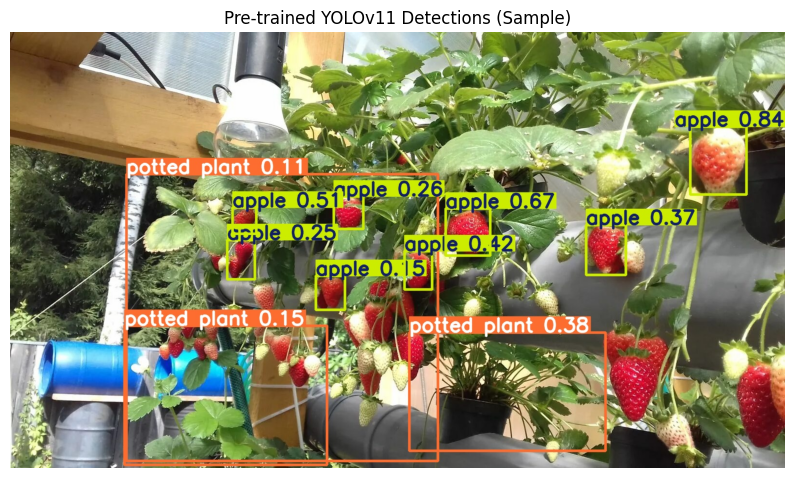

In [5]:
from train_and_infer import run_inference
import torch
val_dir = os.path.join(YOLO_DATASET_DIR, 'images', 'val')
names = [n for n in sorted(os.listdir(val_dir)) if n.lower().endswith(('.png','.jpg','.jpeg'))]
sample_img = os.path.join(val_dir, names[0]) if names else None
print(f"Running pre-trained YOLOv11 inference on sample image {sample_img}...")
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
pretrained_sample_count = run_inference(PRETRAINED_MODEL, sample_img, PRETRAINED_OUT_DIR, conf=0.1, device=device)
print(f"Pre-trained model detected {pretrained_sample_count} strawberries in the sample image.")
pred_name = os.path.basename(sample_img).rsplit('.',1)[0] + '.jpg'
pretrained_result_path = os.path.join(PRETRAINED_OUT_DIR, 'predictions', pred_name)
if os.path.exists(pretrained_result_path):
    pretrained_result = cv2.imread(pretrained_result_path)
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(pretrained_result, cv2.COLOR_BGR2RGB))
    plt.title("Pre-trained YOLOv11 Detections (Sample)")
    plt.axis('off')
    plt.show()
else:
    print(f"Could not find result file at {pretrained_result_path}.")


## 3. Fine-Tuning the YOLOv11 Model

The pre-trained model likely performed poorly because it hasn't been taught to recognize our specific strawberries. Now, we will fine-tune it. We take the pre-trained model and train it further on our labeled strawberry dataset. This teaches the model to become an expert at finding ripe strawberries.

**Note**: Training can take a significant amount of time, depending on your hardware (a GPU is highly recommended). We'll run it for just 25 epochs here as a demonstration. For best results, 100+ epochs are recommended.

## Enabling CUDA Support

To run training on GPU with CUDA, follow these steps:

1. Verify you have an NVIDIA GPU and the correct drivers installed:
   - Open the NVIDIA Control Panel or run `nvidia-smi` in PowerShell.
2. Install the CUDA Toolkit compatible with your GPU (e.g., CUDA 11.x):
   - Download from https://developer.nvidia.com/cuda-toolkit and follow the installer instructions.
3. Install PyTorch with CUDA support in your virtual environment:
   - Using pip:
     ```powershell
     pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu117
     ```
   - Or using conda:
     ```powershell
     conda install pytorch torchvision torchaudio cudatoolkit=11.7 -c pytorch
     ```
4. Restart your environment and confirm in Python:
   ```python
   import torch
   print(torch.cuda.is_available(), torch.cuda.device_count())
   ```

After completing these steps, rerun the training cell; it should detect and use your GPU.


In [6]:
import torch
print(torch.cuda.is_available(), torch.cuda.device_count())

True 1


## Troubleshooting GPU NMS Errors

If you see a `NotImplementedError` related to `torchvision::nms` on the CUDA backend, it means your `torchvision` build does not support GPU NMS. To fix this:

1. Uninstall any CPU-only versions:
   ```powershell
   pip uninstall -y torch torchvision
   ```
2. Reinstall PyTorch and torchvision with CUDA support (example for CUDA 11.7):
   ```powershell
   pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu117
   ```
3. Restart your environment.
4. Rerun the diagnostic cell below to confirm NMS on GPU.


In [7]:
from train_and_infer import train_model
import torch

data_yaml_path = os.path.join(YOLO_DATASET_DIR, 'data.yaml')

# Dynamically choose device: GPU if available, else CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

print("Starting YOLOv11 model training...")
# For demonstration, we use a smaller number of epochs.
# We increase the epochs here for better results.
weights_path = train_model(data_yaml_path, epochs=300, device=device)
print(f"Training complete. Best weights saved at: {weights_path}")

Using device: cuda
Starting YOLOv11 model training...
New https://pypi.org/project/ultralytics/8.3.184 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.158  Python-3.12.9 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup

train: Scanning C:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\labels\train.cache... 32 images, 0 backgrounds, 0 corrupt: 100%|██████████| 32/32 [00:00<?, ?it/s]


val: Fast image access  (ping: 0.10.0 ms, read: 496.0106.7 MB/s, size: 1166.6 KB)


val: Scanning C:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\labels\val.cache... 8 images, 0 backgrounds, 0 corrupt: 100%|██████████| 8/8 [00:00<?, ?it/s]


Plotting labels to output\train\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to output\train
Starting training for 300 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all          8         79      0.946      0.734      0.885      0.582
Speed: 0.4ms preprocess, 10.2ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to output\train
Ultralytics 8.3.158  Python-3.12.9 torch-2.7.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2193.6623.7 MB/s, size: 1668.4 KB)


val: Scanning C:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\labels\val.cache... 8 images, 0 backgrounds, 0 corrupt: 100%|██████████| 8/8 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:04<00:00,  4.37s/it]


                   all          8         79      0.947      0.734      0.884      0.579
Speed: 3.3ms preprocess, 42.0ms inference, 0.0ms loss, 5.3ms postprocess per image
Results saved to output\val


2025-08-24 21:08:55,545 - INFO - Validation metrics: {'metrics/precision(B)': np.float64(0.9466030779659758), 'metrics/recall(B)': np.float64(0.7341772151898734), 'metrics/mAP50(B)': np.float64(0.8842871265592139), 'metrics/mAP50-95(B)': np.float64(0.5794882785671164), 'fitness': np.float64(0.6099681633663261)}
2025-08-24 21:08:55,546 - INFO - Training complete. Best weights at: output\train\weights\best.pt


Training complete. Best weights saved at: output\train\weights\best.pt


### Visualizing Training Results

After training, the `ultralytics` library saves several useful plots in the `output/train/` directory. Let's look at the results graph, which shows how metrics like precision and recall improved over the training epochs, and the confusion matrix.

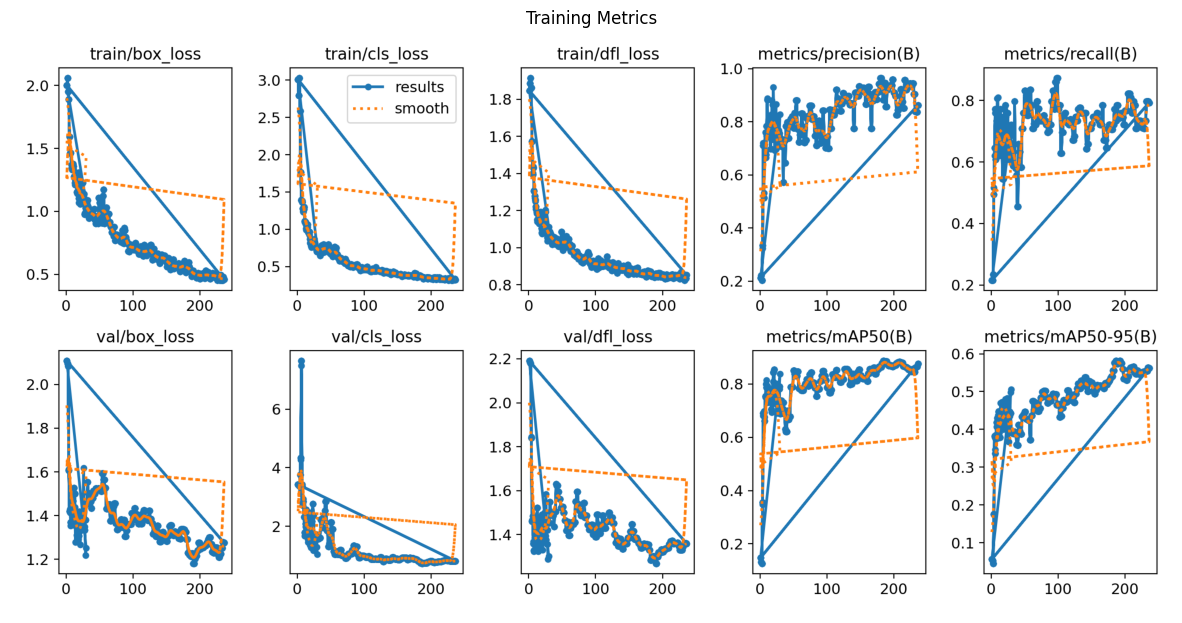

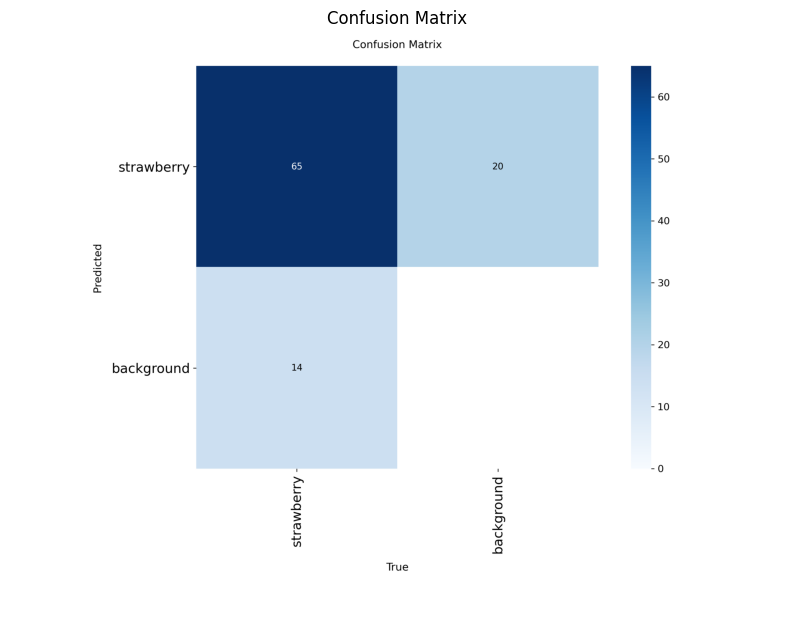

In [8]:
# Display the training results plot and confusion matrix
results_plot_path = os.path.join('output', 'train', 'results.png')
confusion_matrix_path = os.path.join('output', 'train', 'confusion_matrix.png')

if os.path.exists(results_plot_path):
    results_img = cv2.imread(results_plot_path)
    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(results_img, cv2.COLOR_BGR2RGB))
    plt.title("Training Metrics")
    plt.axis('off')
    plt.show()
else:
    print(f"Could not find training results plot at {results_plot_path}")

if os.path.exists(confusion_matrix_path):
    cm_img = cv2.imread(confusion_matrix_path)
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(cm_img, cv2.COLOR_BGR2RGB))
    plt.title("Confusion Matrix")
    plt.axis('off')
    plt.show()
else:
    print(f"Could not find confusion matrix at {confusion_matrix_path}")

## 4. Inference with the Fine-Tuned Model

With our newly fine-tuned model, let's run inference on the same validation images and see the difference. We expect a significant improvement in detection accuracy.

### Note on Directory Inference
This cell runs inference on the entire validation directory (8 images). Each image in the `val` folder is processed, which is why you see outputs for all of them. If you only want to view detections on a single image, use the sample inference cell above instead.

Running fine-tuned YOLOv11 inference on sample image c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\images\val\1.png...

image 1/1 c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\images\val\1.png: 384x640 15 strawberrys, 56.3ms
Speed: 8.2ms preprocess, 56.3ms inference, 4.1ms postprocess per image at shape (1, 3, 384, 640)
Results saved to c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\output\finetuned_preds\predictions


2025-08-24 21:08:57,045 - INFO - Inference complete. Found 15 strawberry detections.


Fine-tuned model detected 15 strawberries in the sample image.


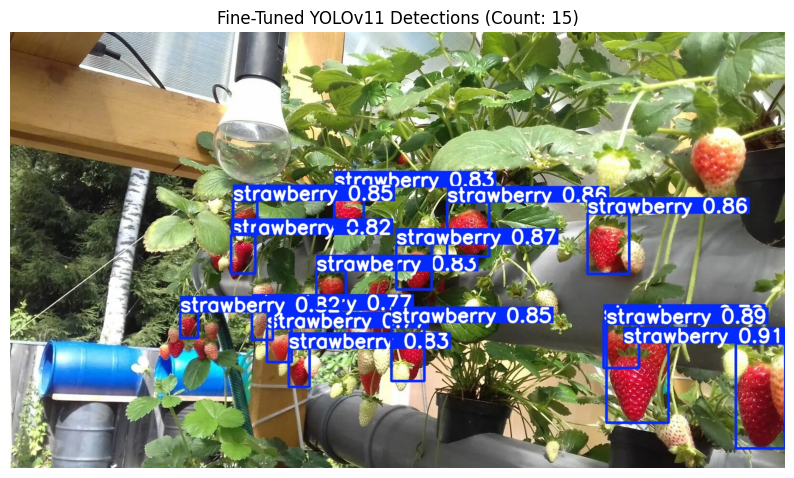

In [9]:
finetuned_weights = os.path.join('output', 'train', 'weights', 'best.pt')
val_dir = os.path.join(YOLO_DATASET_DIR, 'images', 'val')
names = [n for n in sorted(os.listdir(val_dir)) if n.lower().endswith(('.png','.jpg','.jpeg'))]
sample_img = os.path.join(val_dir, names[0]) if names else None
print(f"Running fine-tuned YOLOv11 inference on sample image {sample_img}...")
import torch
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
finetuned_count = run_inference(finetuned_weights, sample_img, FINETUNED_OUT_DIR, conf=0.70, device=device)
print(f"Fine-tuned model detected {finetuned_count} strawberries in the sample image.")
pred_filename = os.path.basename(sample_img).rsplit('.',1)[0] + '.jpg'
pred_path = os.path.join(FINETUNED_OUT_DIR, 'predictions', pred_filename)
if os.path.exists(pred_path):
    pred_img = cv2.imread(pred_path)
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Fine-Tuned YOLOv11 Detections (Count: {finetuned_count})")
    plt.axis('off')
    plt.show()
else:
    print(f"Could not find result file at {pred_path}")


In [10]:
def detect_and_show(weights_path, image_path, output_dir, conf=0.7, title_prefix="Detections", device=None):
    if device is None:
        import torch
        device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    print(f"Running inference on {image_path} with weights {weights_path}...")
    count = run_inference(weights_path, image_path, output_dir, conf=conf, device=device)
    pred_name = os.path.basename(image_path).rsplit('.',1)[0] + '.jpg'
    pred_path = os.path.join(output_dir, 'predictions', pred_name)
    if os.path.exists(pred_path):
        img = cv2.imread(pred_path)
        plt.figure(figsize=(10,8))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"{title_prefix} (Count: {count})")
        plt.axis('off')
        plt.show()
    else:
        print(f"Could not find prediction at {pred_path}")
    return count


Running inference on c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\images\val\15.png with weights output\train\weights\best.pt...

image 1/1 c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\images\val\15.png: 480x640 6 strawberrys, 111.7ms
Speed: 4.4ms preprocess, 111.7ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\output\finetuned_preds\predictions


2025-08-24 21:08:57,887 - INFO - Inference complete. Found 6 strawberry detections.


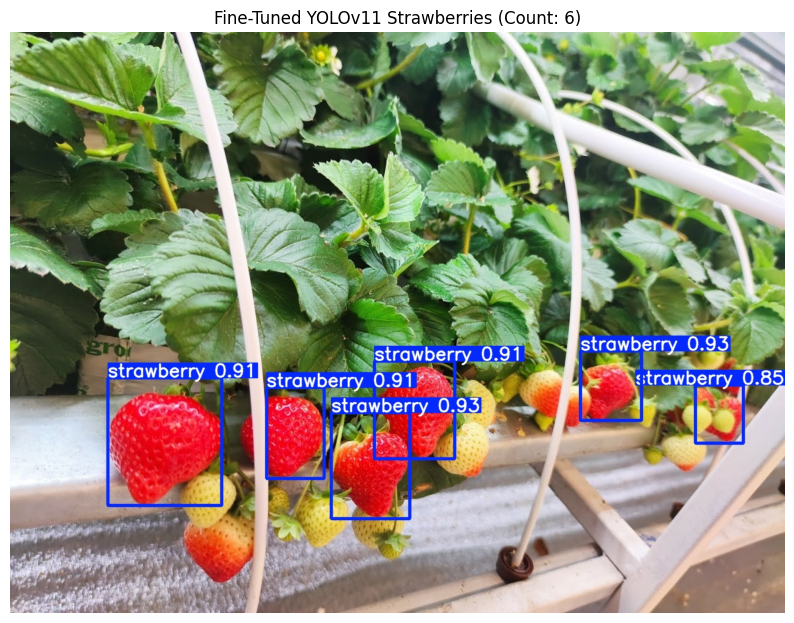

In [11]:
finetuned_weights = os.path.join('output','train','weights','best.pt')
import torch
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
count = detect_and_show(
    finetuned_weights,
    os.path.join(YOLO_DATASET_DIR,'images','val','15.png'),
    FINETUNED_OUT_DIR,
    conf=0.70,
    title_prefix="Fine-Tuned YOLOv11 Strawberries",
    device=device
)


Running inference on c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\images\val\16.png with weights output\train\weights\best.pt...

image 1/1 c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\strawberry_dataset\images\val\16.png: 448x640 9 strawberrys, 90.7ms
Speed: 2.4ms preprocess, 90.7ms inference, 2.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to c:\Users\wbrya\OneDrive\Documents\GitHub\ripe-strawberry-detector\output\finetuned_preds\predictions


2025-08-24 21:08:58,643 - INFO - Inference complete. Found 9 strawberry detections.


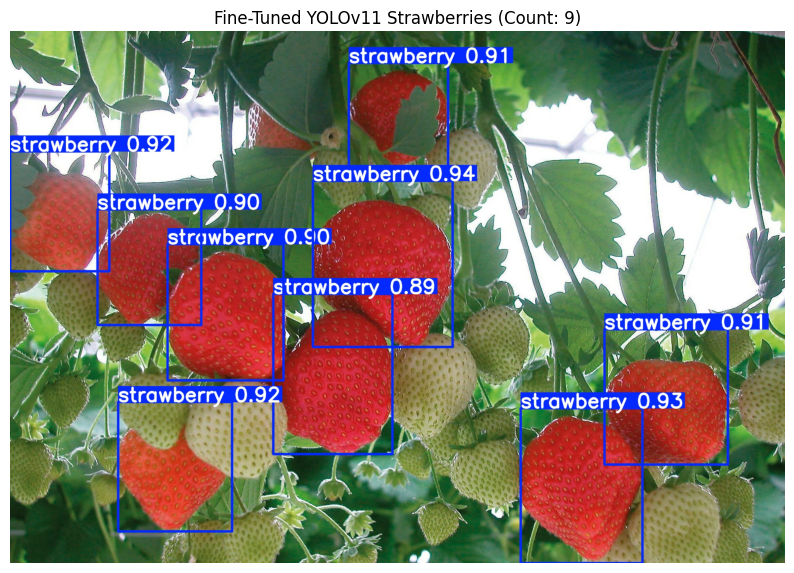

In [12]:
import torch
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
count = detect_and_show(
    finetuned_weights,
    os.path.join(YOLO_DATASET_DIR,'images','val','16.png'),
    FINETUNED_OUT_DIR,
    conf=0.70,
    title_prefix="Fine-Tuned YOLOv11 Strawberries",
    device=device
)
